# Demo of Convolutional Neural Network from Scratch

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix

from src.layers import Conv2D, MaxPool, Flatten, FullyConnected, BatchNorm2D, ReLU
from src.activations import relu, softmax
from src.losses import cross_entropy_loss
from src.optimizers import Adam   
from src.model import Model 
from src.train import train, one_hot

## Data Loading

First step before splitting the data into trainable data is to fetch version one of MNIST from scikit learn as the data we're going to train our Convolutional Neural Network on. This will provide the images and labels, allowing us to see how efficient our model operates.

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

## Data Preprocessing

### Splitting the Data into Appropriate Sections

The next step is for us to drop off pieces of data into a training and test labels and images, to first train our model up, then to see it's accuracy after.

In [3]:
# training images and labels
x_train = mnist.data[:10000].reshape(10000, 1, 28, 28) 
y_train = mnist.target[:10000].astype(int)

# test images and labels
x_test = mnist.data[60000:].reshape(-1, 1, 28, 28)
y_test = mnist.target[60000:].astype(int)

### Normalizing Data
The next step is to normalize the data to ensure that is able to train properly and eliminate any possible outliers which might impact the data by making all the `x_train` and `x_test` (images) a value from range of **0.0** to **1.0** by dividing it by **255** as colors range on that scale.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### One-hot Encoding

For the labels (`y_train` and `y_test`) it is necessary to use one-hot encoding in order for the data outputted to match that of the data outputted by the fully connected layer and softmax in the convolutional neural network.

In [5]:
y_train = one_hot(y_train, num_classes=10)
y_test = one_hot(y_test, num_classes=10)

### Verifiying Data

The first step we take into verifying the data is seeing if it is appropriately displaying the images in a correct black and white format and, is able to display the appropriate and related labels to it in the right format.

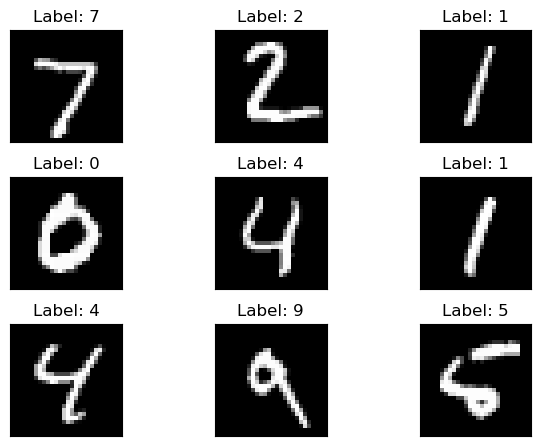

In [6]:
fig = plt.figure()
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.tight_layout()
    plt.imshow(x_test[i][0], cmap='gray', interpolation='none')
    plt.title("Label: {}".format(np.argmax(y_test[i])))    
    plt.xticks([])
    plt.yticks([])
plt.show()


The next initiative to take is ensuring that the data is split across the different labels in an appropriate manner, and to display that we will be using a bar chart as a measure of ensuring the data is loaded correctly.

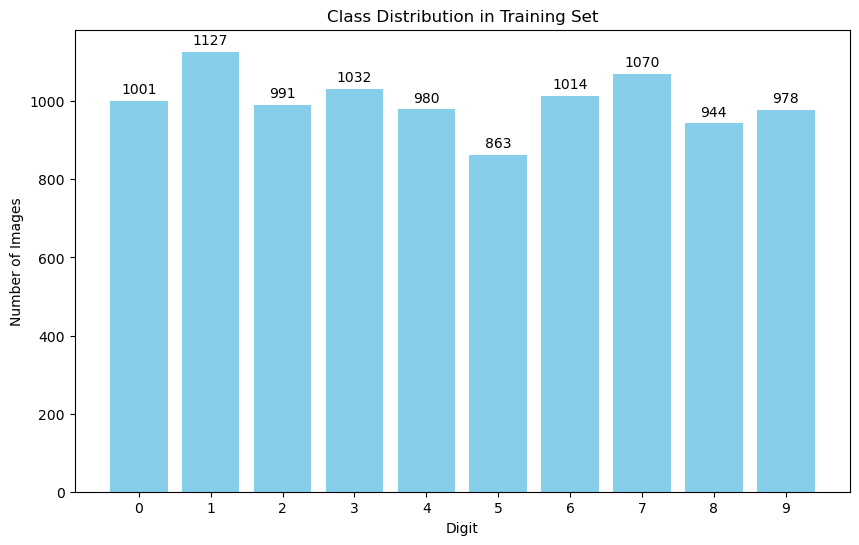

In [7]:
y_train_labels = np.argmax(y_train, axis=1)   # (60000, 10) → (60000,)

counts = pd.Series(y_train_labels).value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color='skyblue')
plt.bar_label(bars, padding=3)
plt.title('Class Distribution in Training Set')
plt.xlabel('Digit')
plt.ylabel('Number of Images')
plt.xticks(range(10))  
plt.show()

We then have to ensure ourselves that the training images are appropriately normalized, and we can see this through a histogram, this histogram would display the amount of frequency for each pixel intensity and with it being black and white images now we can massively expect spikes at the 0.0 and 1.0 pixel intensity.

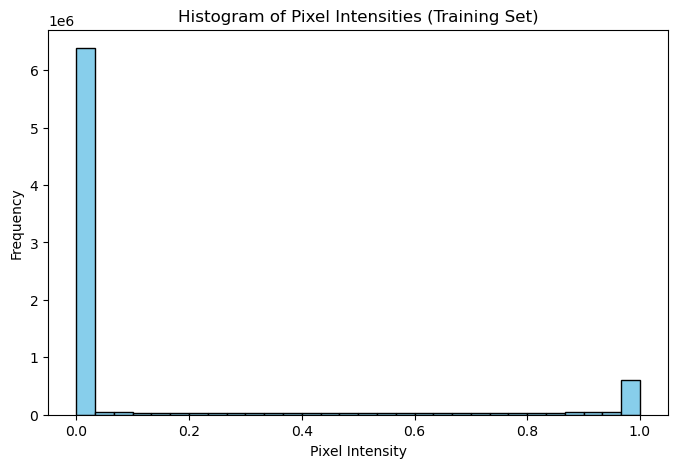

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(x_train.flatten(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of Pixel Intensities (Training Set)')
plt.show()

## Training the Model

### Running the Training

Now comes the time after validating the data that will be used to train the model we can call upon train with these variables (labels and images) and now see how the overall model performs with such data. There will perferably be the usage of 10000 training images and labels used over each epoch to train the model, and we will go through 30 epochs.

In [9]:
epochs = 30

loss_history, train_acc_history, predicted_classes_history, true_classes_history = train(x_train, y_train, epochs)

epoch: 1   loss: 0.359   train acc: 0.891
epoch: 2   loss: 0.106   train acc: 0.968
epoch: 3   loss: 0.07   train acc: 0.98
epoch: 4   loss: 0.05   train acc: 0.986
epoch: 5   loss: 0.04   train acc: 0.988
epoch: 6   loss: 0.029   train acc: 0.993
epoch: 7   loss: 0.022   train acc: 0.993
epoch: 8   loss: 0.015   train acc: 0.996
epoch: 9   loss: 0.013   train acc: 0.995
epoch: 10   loss: 0.01   train acc: 0.996
epoch: 11   loss: 0.007   train acc: 0.997
epoch: 12   loss: 0.004   train acc: 0.999
epoch: 13   loss: 0.004   train acc: 0.999
epoch: 14   loss: 0.004   train acc: 0.999
epoch: 15   loss: 0.003   train acc: 0.999
epoch: 16   loss: 0.001   train acc: 1.0
epoch: 17   loss: 0.001   train acc: 1.0
epoch: 18   loss: 0.0   train acc: 1.0
epoch: 19   loss: 0.0   train acc: 1.0
epoch: 20   loss: 0.003   train acc: 0.999
epoch: 21   loss: 0.008   train acc: 0.997
epoch: 22   loss: 0.003   train acc: 0.999
epoch: 23   loss: 0.001   train acc: 1.0
epoch: 24   loss: 0.001   train acc: 1.

### Plotting the Training Accuracy

Now that the model has finished training, its time to analyze the model performance, especially how the loss is plotted over the epochs to understand where the model stagnates, and the overall performance of it. The next is to plot the accuracy over the epochs, too see where the performance of the model reaches its peak, and to help with diagnosing where the model fails to perform, whether it's overfitting, a poor learning rate, incorrect formulas that might be utilized, or something else. Finally, we will create a confusion matrix to dislpay where the model might mix up certain items, and where it might fail to perform.

#### Plotting the Loss over the Epochs

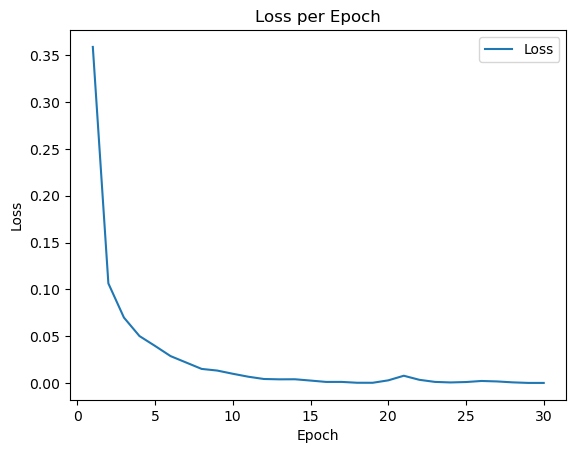

In [10]:
epochs = range(1, len(loss_history) + 1)

plt.plot(epochs, loss_history, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.show()

The results show a reasonable curve during the training procedure, indicating that the model is working as expected, in addition, the smooth curve is a clear indicator of no noise being present. To add on, we observve the model stagnated are the 15th epoch, which is a clear indication that we might be overtraining our model, however, it is a good indication as out model approaches 0.

#### Plotting the Accuracy over the Epochs

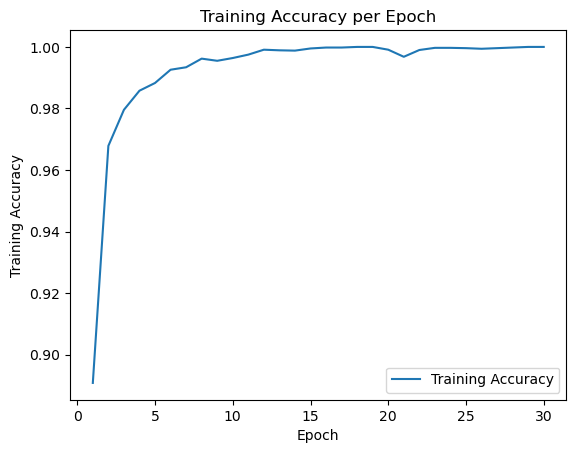

In [11]:
plt.plot(epochs, train_acc_history, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy per Epoch')
plt.legend()
plt.show()

Once again, there's a clear indication of the correct result being output, as we see the training accuracy curve smoothly slow down in it's learning rate and is slowing down at a rate of that similar to the loss per epoch, indicating the model is conducting forward and backward passes without issue. We can also see that the model tends to peak and stagnate around 1.00 indicating that the model achieves a near perfect match between the labels and images.

#### Confusion Matrix

In [13]:
true_classes_history = np.concatenate(true_classes_history)
predicted_classes_history = np.concatenate(predicted_classes_history)

matrix = confusion_matrix(true_classes_history, predicted_classes_history)
print(matrix)

# Normalize for percentages (optional but often clearer)
matrix_norm = matrix.astype('float') / matrix.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

ValueError: zero-dimensional arrays cannot be concatenated